## Attention, pour exécuter toute la page il faut à peu prés 2 heures !!!

In [23]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer, RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder




pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [24]:
def contaminant(x):
    if x in ["Neige fraiche (B)", "Neige fraiche (G)"]:
        return "Neige fraiche"
    elif x in ["N.C. (G)","N.C. (B)"]:
        return "N.C."
    else:
        return x
        
df = pd.read_csv('Data_Modelisation-3.csv')
df.Vitesse = df.Vitesse.astype(str)

In [25]:
df.columns

Index(['Vitesse', 'Glissement', 'Moyenne CFL F', 'Moyenne CFL C',
       'Moyenne G% [%]', 'Fv (kg)', 'Tsurf (C)', 'T° BDR (C)', 'Contaminant',
       'hauteur (mm)'],
      dtype='object')

In [26]:
df = df[df.Contaminant != "DRY"]
df["contaminant"] = df.Contaminant.apply(contaminant)

df = df.drop(['Fv (kg)', 'Tsurf (C)', 'T° BDR (C)', 'Contaminant','hauteur (mm)'], axis=1)

In [27]:
def scale_encode(x, y=0):
    encoder = OneHotEncoder(drop='first')
    # Séparer les variables qualitatives et numériques
    qualitative_vars = ['Vitesse']
    numeric_vars = x.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    # Appliquer le one-hot encoding aux variables qualitatives
    encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
    encoded_columns = encoder.get_feature_names_out(qualitative_vars)
    encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns, index=x.index)
    
    if y == 1:  # Appliquer le StandardScaler aux variables numériques
        scaler = StandardScaler().set_output(transform='pandas')
    elif y == 2:  # Appliquer le Normalizer aux variables numériques
        scaler = Normalizer().set_output(transform='pandas')
    else:
        X = pd.concat([x.drop(qualitative_vars, axis=1), encoded_df], axis=1)
        return X
    
    # Appliquer le scaler et transformer les variables numériques
    scaled_df = scaler.fit_transform(x[numeric_vars])
    
    # Concaténation des DataFrames encodé et standardisé
    X = pd.concat([scaled_df, encoded_df], axis=1)
    return X

## Classification par apprentissage supervisé régression logistique multimodale

Dans cette partie on reprend la base de données dont on a verifié la repetabilité et la reproductibilité, pour faire une classification des contaminant, on va commencer tout d'abord par une regression logistique, on va expliquer apres pourquoi ce modele n'est pas adapté pour ce probleme, on va alors entrainer un modele des forest aleatoires, puis on va appliquer ce model sur les observations à 65km/h et 15% de glissement, puis on va comparer les resultats avec la partie precedente.

In [28]:
df.contaminant.value_counts()

contaminant
Neige fraiche    320
N.C.             246
NC.C.            232
Glace            107
SLUSH             70
Verglas           58
Name: count, dtype: int64

In [32]:
df.columns

Index(['Vitesse', 'Glissement', 'Moyenne CFL F', 'Moyenne CFL C',
       'Moyenne G% [%]', 'contaminant'],
      dtype='object')

In [41]:
X = df[df["contaminant"]!="Verglas"][['Vitesse', 'Moyenne CFL C','Moyenne G% [%]']].copy()
X = scale_encode(X,0)


X["V*CFL"] = X['Vitesse_65']*X["Moyenne CFL C"]
X["g*CFL"] = X['Moyenne G% [%]']*X["Moyenne CFL C"]
# X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']
X["g*V*CFL"] = X['Moyenne G% [%]']*X['Vitesse_65']*X["Moyenne CFL C"]
#X=X.drop(['Vitesse_65','Moyenne G% [%]'],axis=1)

#X.drop(['Vitesse_65','Moyenne G% [%]'],axis=1)

y = df[df["contaminant"]!="Verglas"]['contaminant']

In [42]:
X.columns

Index(['Moyenne CFL C', 'Moyenne G% [%]', 'Vitesse_65', 'V*CFL', 'g*CFL',
       'g*V*CFL'],
      dtype='object')

### Regression logistique

En appliquant un modèle de regression logistique, on obtient les resultats suivant:


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = y, random_state=123)#9  12  21 27 29 38 48 49 87 110 #49 68 76 94 95 100 101 108 118 128 124 204 290 283
log_reg = LogisticRegression(max_iter=10000, class_weight='balanced',solver='lbfgs') 
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
#print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

        Glace       0.83      0.90      0.86        21
         N.C.       0.41      0.18      0.25        49
        NC.C.       0.59      0.57      0.58        47
Neige fraiche       0.68      0.75      0.71        64
        SLUSH       0.24      0.57      0.34        14

     accuracy                           0.57       195
    macro avg       0.55      0.60      0.55       195
 weighted avg       0.57      0.57      0.55       195



In [44]:
log_reg.classes_

array(['Glace', 'N.C.', 'NC.C.', 'Neige fraiche', 'SLUSH'], dtype=object)

In [45]:
coefficients = log_reg.coef_
intercepts = log_reg.intercept_

# Récupération des classes du modèle pour assurer un alignement correct
classes = log_reg.classes_

# Créer une DataFrame pour afficher les coefficients et les intercepts
dff = pd.DataFrame(coefficients, columns=X.columns, index=classes)
dff['Intercept'] = intercepts

# Reindexer la DataFrame pour correspondre aux modalités
dff.index = ['Glace', 'N.C.', 'NC.C.', 'Neige fraiche', 'SLUSH']
# Afficher la DataFrame
dff

,Moyenne CFL C,Moyenne G% [%],Vitesse_65,V*CFL,g*CFL,g*V*CFL,Intercept
Glace,0.225129,0.648922,-0.247578,0.282869,-5.813473,0.250789,-0.134744
N.C.,1.340400,-0.190656,-0.356366,0.571145,1.595682,0.027681,0.097554
NC.C.,3.098589,-0.245397,-0.360102,1.209183,1.992377,-0.048993,-0.434023
Neige fraiche,1.222663,-0.044379,0.948660,0.454068,0.679137,-0.119231,-0.504267
SLUSH,-5.886781,-0.168490,0.015386,-2.517265,1.546277,-0.110246,0.975480


### Random Forest

Pour avoir le meilleur modele des foret aleatoires, on va chercher la meilleur combinaison des hyperparametres par validation croisée stratifié 5 blocs, on cherche les meilleurs arguments de "random_state", "n_estimators", "max_depth", 'min_samples_split', 'min_samples_leaf', "oob_score" et "class_weight".
Onchosit le meilleur condidat parmi 11520 condidat ce qui provoque 57600 fit (vue le coix de 5 blocs), apres 2 heurs d'entrainement (sachant qu'on a utlisé tous les gpu de la machine en utlilisant l'hyperparametre n_jobs), la meilleurs combinaison des hyperparametres est :
il a donné ces resultats

In [46]:
%%time
# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=123)

# Initialiser le modèle de Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_jobs=-1)

# Définir la grille des hyperparamètres à optimiser
param_grid = {
    "random_state": [2, 40, 45, 18, 61],
    'n_estimators': [100, 150,250],
    "max_depth" : [None, 12, 10],
    'min_samples_split': [1,2,3],
    'min_samples_leaf': [1 ,2,3],
}
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
# Initialiser GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=stratified_kfold, n_jobs=-1, verbose=2, scoring='recall_weighted')

# Entraîner GridSearchCV
grid_search.fit(X_train, y_train)

# Meilleurs paramètres
best_params = grid_search.best_params_
print("Meilleurs paramètres trouvés par GridSearchCV : ", best_params)

# Meilleur modèle entraîné
best_rf = grid_search.best_estimator_

# Faire des prédictions sur l'ensemble de test
y_pred = best_rf.predict(X_test)


# Afficher le rapport de classification et la matrice de confusion
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred))



Fitting 5 folds for each of 405 candidates, totalling 2025 fits
Meilleurs paramètres trouvés par GridSearchCV :  {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100, 'random_state': 61}

Classification Report:
               precision    recall  f1-score   support

        Glace       0.86      0.90      0.88        21
         N.C.       0.68      0.61      0.65        49
        NC.C.       0.73      0.74      0.74        47
Neige fraiche       0.80      0.86      0.83        64
        SLUSH       0.75      0.64      0.69        14

     accuracy                           0.76       195
    macro avg       0.76      0.75      0.76       195
 weighted avg       0.76      0.76      0.76       195

CPU times: total: 4.41 s
Wall time: 1min 55s


### XGBoost classifier

Pour obtenir le meilleur modèle de classification par modele de XGBoost, nous allons rechercher la meilleure combinaison d’hyperparamètres par validation croisée stratifiée en 5 blocs. Les hyperparamètres à optimiser sont : "random state", "n estimators", "max depth", "min_child_weight", "learning_rate", "colsample_bytree", "subsample"
Nous choisirons le meilleur candidat parmi 4608 combinaisons possibles, ce qui entraîne 23040 ajustements (en raison de la validation croisée en 5 bloc), le modele a pris à peu pret 30 minutes pour s'entrainer (meme si on a utiliser tous les coeurs de la machine à l'aide de l'hyperparametre n_jobs), finallement la meilleure combinaison des hyperparamètres est:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 250, 'random_state': 123, 'subsample': 0.8}
nous avons obtenu les résultats suivants :

In [48]:
%%time
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X.columns = ['Moyenne_CFL_C', 'g', 'Vitesse_65', 'V*CFL', 'g*CFL',
       'g*V*CFL']
# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=123)

# Initialiser le modèle XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Définir la grille des hyperparamètres à optimiser
param_grid = {
    'n_estimators': [100, 150, 250],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initialiser GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=stratified_kfold, n_jobs=-1, verbose=2, scoring='recall_weighted')

# Entraîner GridSearchCV
grid_search.fit(X_train, y_train)

# Meilleurs paramètres
best_params = grid_search.best_params_
print("Meilleurs paramètres trouvés par GridSearchCV : ", best_params)

# Meilleur modèle entraîné
best_xgb = grid_search.best_estimator_

# Faire des prédictions sur l'ensemble de test
y_pred = best_xgb.predict(X_test)

# Convertir les prédictions numériques en étiquettes originales
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

# Afficher le rapport de classification et la matrice de confusion
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels))

# Décommentez les lignes suivantes si vous voulez afficher la matrice de confusion
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test_labels, y_pred_labels))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Meilleurs paramètres trouvés par GridSearchCV :  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 250, 'subsample': 0.8}

Classification Report:
               precision    recall  f1-score   support

        Glace       0.86      0.90      0.88        21
         N.C.       0.68      0.65      0.67        49
        NC.C.       0.76      0.74      0.75        47
Neige fraiche       0.80      0.89      0.84        64
        SLUSH       0.89      0.57      0.70        14

     accuracy                           0.77       195
    macro avg       0.80      0.75      0.77       195
 weighted avg       0.77      0.77      0.77       195

CPU times: total: 13.6 s
Wall time: 1min 25s


In [14]:
%%time
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Encodage des étiquettes de la variable cible
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X.columns = ['Moyenne_CFL_C', 'g', 'Vitesse_65', 'V*CFL', 'g*CFL',
       'g*V*CFL']
# Calculer les poids des classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weights_dict = dict(zip(np.unique(y_encoded), class_weights))
# wi​=n/(k * ni)​   n est le nombre total d'exemples dans l'ensemble de données,  k est le nombre de classes uniques,  ni​ est le nombre d'exemples de la classe i.

# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=123)

# Créer un tableau de poids pour les échantillons d'entraînement
sample_weights = np.array([class_weights_dict[class_label] for class_label in y_train])

# Initialiser le modèle XGBoost
xgb_model = xgb.XGBClassifier(objective='multi:softmax', use_label_encoder=False, eval_metric='mlogloss')

# Définir la grille des hyperparamètres à optimiser
param_grid = {
    "random_state": [2, 40, 45, 18, 61, 123],
    'n_estimators': [100, 150, 250, 300],
    "max_depth": [3, 5, 6, 10],
    'min_child_weight': [1, 2, 3],
    'learning_rate': [0.3, 0.1, 0.2, 0.25],
    'colsample_bytree': [0.8, 1.0],
    'subsample': [0.8, 1.0],
}

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initialiser GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=stratified_kfold, n_jobs=-1, verbose=2, scoring='recall_weighted')

# Entraîner GridSearchCV avec les poids d'échantillon
grid_search.fit(X_train, y_train, sample_weight=sample_weights)

# Meilleurs paramètres
best_params = grid_search.best_params_
print("Meilleurs paramètres trouvés par GridSearchCV : ", best_params)

# Meilleur modèle entraîné
best_xgb = grid_search.best_estimator_

# Faire des prédictions sur l'ensemble de test
y_pred = best_xgb.predict(X_test)

# Décoder les étiquettes prédites pour correspondre aux étiquettes originales
y_pred_decoded = label_encoder.inverse_transform(y_pred)
y_test_decoded = label_encoder.inverse_transform(y_test)

# Afficher le rapport de classification et la matrice de confusion
print("\nClassification Report:")
print(classification_report(y_test_decoded, y_pred_decoded))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test_decoded, y_pred_decoded))

Fitting 5 folds for each of 4608 candidates, totalling 23040 fits


KeyboardInterrupt: 

In [56]:
class_weights_dict

{0: 1.8224299065420562,
 1: 0.7926829268292683,
 2: 0.8405172413793104,
 3: 0.609375,
 4: 2.7857142857142856}

### Vitesse 65 glissement 15 (Sans slush et verglas)

#### Random forest 

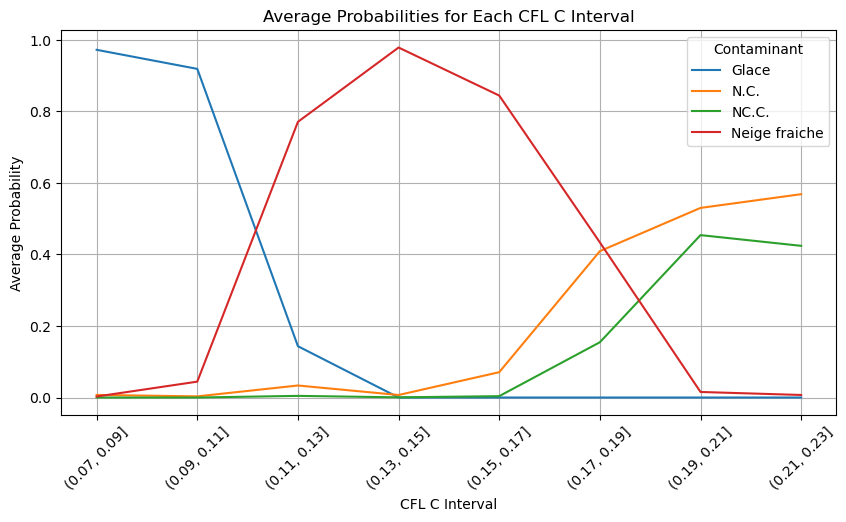

,Glace,N.C.,NC.C.,Neige fraiche,True Label,Predicted Label
CFL C Interval,,,,,,
"(0.07, 0.09]",0.972456,0.007221,0.000000,0.002779,Glace,Glace
"(0.09, 0.11]",0.919135,0.003220,0.000000,0.044406,Glace,Glace
"(0.11, 0.13]",0.143481,0.033612,0.004586,0.771036,Neige fraiche,Neige fraiche
"(0.13, 0.15]",0.000000,0.007057,0.000492,0.978868,Neige fraiche,Neige fraiche
"(0.15, 0.17]",0.000000,0.070823,0.003818,0.844523,Neige fraiche,Neige fraiche
"(0.17, 0.19]",0.000000,0.409345,0.154623,0.433783,Neige fraiche,Neige fraiche
"(0.19, 0.21]",0.000000,0.530288,0.454193,0.015520,N.C.,NC.C.
"(0.21, 0.23]",0.000000,0.568675,0.424201,0.007124,NC.C.,N.C.


In [16]:

dff = scale_encode(df, 0).copy()

# Filtrer les données
X_65_15 = dff[(~(dff["contaminant"].isin(["Verglas", "SLUSH"])))][['Moyenne CFL C', 'Moyenne G% [%]', 'Vitesse_65']].copy()
X_65_15 = X_65_15[(X_65_15['Moyenne G% [%]'] > 14) & (X_65_15['Moyenne G% [%]'] < 16) & (X_65_15.Vitesse_65 == 1)]

# Calculer des nouvelles colonnes
X_65_15["V*CFL"] = X_65_15['Vitesse_65'] * X_65_15["Moyenne CFL C"]
X_65_15["g*CFL"] = X_65_15['Moyenne G% [%]'] * X_65_15["Moyenne CFL C"]
X_65_15["g*V*CFL"] = X_65_15['Moyenne G% [%]'] * X_65_15['Vitesse_65'] * X_65_15["Moyenne CFL C"]

# Définir y_65_15
y_65_15 = dff[(~(dff["contaminant"].isin(["Verglas", "SLUSH"]))) & (dff['Moyenne G% [%]'] > 14) & (dff['Moyenne G% [%]'] < 16) & (dff.Vitesse_65 == 1)]['contaminant']

# Prédire les probabilités
y_proba_rf = best_rf.predict_proba(X_65_15)

# Créer un DataFrame de résultats
results_df = pd.DataFrame(X_65_15.reset_index(), columns=['Moyenne CFL C'])
results_df['True Label'] = y_65_15.values
results_df = results_df.join(pd.DataFrame(y_proba_rf, columns=best_rf.classes_))

# Déterminer le label prédit avec la plus grande probabilité
results_df['Predicted Label'] = results_df[best_rf.classes_].idxmax(axis=1)

# Définir des bins personnalisés avec un pas de 0.02
bin_edges = np.arange(0.07, 0.24, 0.02)
results_df['CFL C Interval'] = pd.cut(results_df['Moyenne CFL C'], bins=bin_edges)

# Calculer les probabilités et les valeurs les plus fréquentes
interval_probs = results_df.groupby('CFL C Interval')[['Glace', "N.C.", "NC.C.", "Neige fraiche"]].mean()
interval_counts = results_df.groupby('CFL C Interval')[['True Label', 'Predicted Label']].agg(lambda x: x.value_counts().index[0])
interval_probs = interval_probs.join(interval_counts)

# Afficher les résultats
plt.figure(figsize=(10, 5))
for class_label in ['Glace', 'N.C.', 'NC.C.', 'Neige fraiche']:
    plt.plot(interval_probs.index.astype(str), interval_probs[class_label], label=class_label)

plt.xlabel('CFL C Interval')
plt.ylabel('Average Probability')
plt.title('Average Probabilities for Each CFL C Interval')
plt.legend(title='Contaminant')
plt.xticks(rotation=45)
plt.grid()
plt.show()
interval_probs

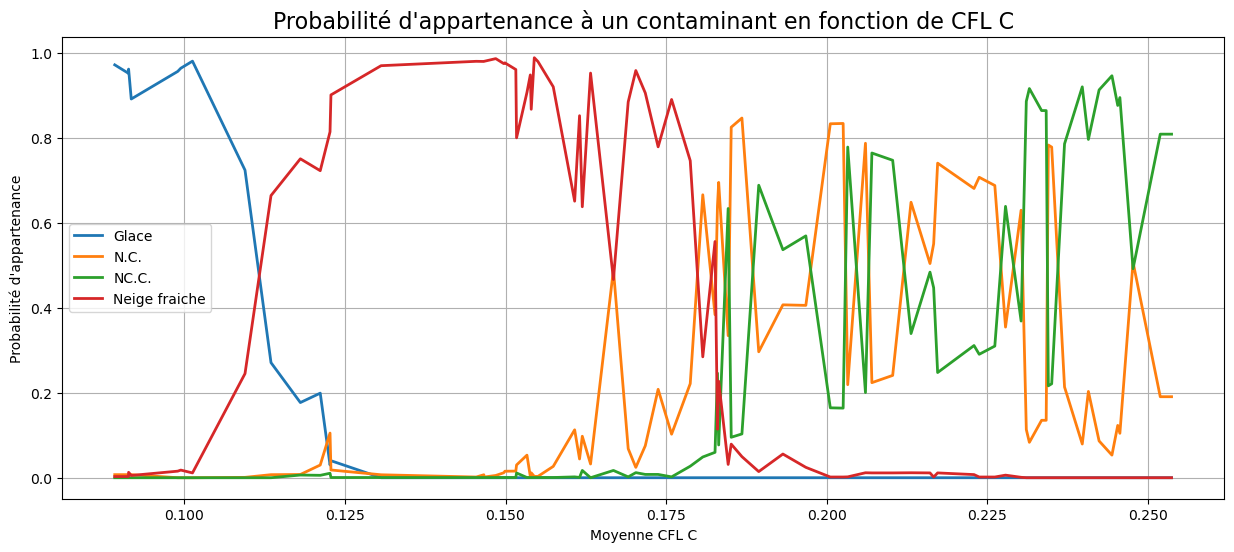

In [17]:
plt.figure(figsize=(15, 6))

a = results_df.sort_values(["Moyenne CFL C"])
plt.plot(a['Moyenne CFL C'], a['Glace'], label='Glace', linewidth=2)
plt.plot(a['Moyenne CFL C'], a['N.C.'], label='N.C.', linewidth=2)
plt.plot(a['Moyenne CFL C'], a['NC.C.'], label='NC.C.', linewidth=2)
plt.plot(a['Moyenne CFL C'], a['Neige fraiche'], label='Neige fraiche', linewidth=2)

# Set labels and title
plt.xlabel('Moyenne CFL C')
plt.ylabel('Probabilité d\'appartenance')
plt.title('Probabilité d\'appartenance à un contaminant en fonction de CFL C', fontsize=16)

# Add grid and legend
plt.grid(True)
plt.legend()

# Show plot
plt.show()

#### XGBoost

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Préparation des données
dff = scale_encode(df, 0).copy()

# Filtrage des données
X_65_15 = dff[(~(dff["contaminant"].isin(["Verglas", "SLUSH"])))][['Moyenne CFL C', 'Moyenne G% [%]', 'Vitesse_65']].copy()
X_65_15 = X_65_15[(X_65_15['Moyenne G% [%]'] > 14) & (X_65_15['Moyenne G% [%]'] < 16) & (X_65_15.Vitesse_65 == 1)]

# Calcul des nouvelles colonnes
X_65_15["V*CFL"] = X_65_15['Vitesse_65'] * X_65_15["Moyenne CFL C"]
X_65_15["g*CFL"] = X_65_15['Moyenne G% [%]'] * X_65_15["Moyenne CFL C"]
X_65_15["g*V*CFL"] = X_65_15['Moyenne G% [%]'] * X_65_15['Vitesse_65'] * X_65_15["Moyenne CFL C"]

# Renommage des colonnes pour correspondre au modèle
X_65_15.columns = ['Moyenne_CFL_C', 'g', 'Vitesse_65', 'V*CFL', 'g*CFL', 'g*V*CFL']

# Définition de y_65_15
y_65_15 = dff[(~(dff["contaminant"].isin(["Verglas", "SLUSH"]))) & 
              (dff['Moyenne G% [%]'] > 14) & 
              (dff['Moyenne G% [%]'] < 16) & 
              (dff.Vitesse_65 == 1)]['contaminant']

# Prédiction des probabilités
y_proba_xgb = best_xgb.predict_proba(X_65_15)

# Création du DataFrame de résultats
results_df = pd.DataFrame(X_65_15.reset_index(), columns=['Moyenne_CFL_C'])
results_df['True Label'] = y_65_15.values
results_df = results_df.join(pd.DataFrame(y_proba_xgb, columns=best_xgb.classes_))

# Mapping function for predicted labels
def f(x):
    if x == 0:
        return "Glace"
    elif x == 1:
        return 'N.C.'
    elif x == 2:
        return 'NC.C.'
    elif x == 3:
        return 'Neige fraiche'
    else:
        return 'SLUSH'
        
results_df['Predicted Label'] = results_df[best_xgb.classes_].idxmax(axis=1).apply(f)
results_df.columns = ['Moyenne_CFL_C', 'True Label', 'Glace', 'N.C.', 'NC.C.', 'Neige fraiche', 'SLUSH', 'Predicted Label']

# Définition des bins personnalisés avec un pas de 0.02
bin_edges = np.arange(0.08, 0.27, 0.02)
results_df['CFL_C_Interval'] = pd.cut(results_df['Moyenne_CFL_C'], bins=bin_edges)

# Calcul des probabilités et des valeurs les plus fréquentes
interval_probs = results_df.groupby('CFL_C_Interval')[['Glace', "N.C.", "NC.C.", "Neige fraiche"]].mean()
interval_counts = results_df.groupby('CFL_C_Interval')[['True Label', 'Predicted Label']].agg(lambda x: x.value_counts().index[0])
interval_probs = interval_probs.join(interval_counts)

# Ajout de la première ligne spécifiée
first_row = pd.DataFrame({
    'Glace': [1.0],
    'N.C.': [0.0],
    'NC.C.': [0.0],
    'Neige fraiche': [0.0],
    'True Label': ['Glace'],
    'Predicted Label': ['Glace']
}, index=pd.IntervalIndex.from_tuples([(0.06, 0.08)], closed='right'))

interval_probs = pd.concat([first_row, interval_probs])

# Fonction pour trouver la colonne avec la valeur maximale
def find_max_label(row):
    return row[['Glace', 'N.C.', 'NC.C.', 'Neige fraiche']].idxmax()

# Mise à jour de la colonne 'Predicted Label'
interval_probs["Predicted Label"] = interval_probs.apply(find_max_label, axis=1)

# Affichage des résultats
plt.figure(figsize=(10, 5))
for class_label in ['Glace', "N.C.", "NC.C.", "Neige fraiche"]:
    plt.plot(interval_probs.index.astype(str), interval_probs[class_label], label=class_label)
plt.xlabel('CFL C Interval')
plt.ylabel('Average Probability')
plt.title('Average Probabilities for Each CFL C Interval')
plt.legend(title='Contaminant')
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Affichage du DataFrame interval_probs
(interval_probs)


NameError: name 'best_xgb' is not defined

In [ ]:
plt.figure(figsize=(15, 6))

a = results_df.sort_values(["Moyenne_CFL_C"])
plt.plot(a['Moyenne_CFL_C'], a['Glace'], label='Glace', linewidth=2)
plt.plot(a['Moyenne_CFL_C'], a['N.C.'], label='N.C.', linewidth=2)
plt.plot(a['Moyenne_CFL_C'], a['NC.C.'], label='NC.C.', linewidth=2)
plt.plot(a['Moyenne_CFL_C'], a['Neige fraiche'], label='Neige fraiche', linewidth=2)

# Set labels and title
plt.xlabel('Moyenne CFL C')
plt.ylabel('Probabilité d\'appartenance')
plt.title('Probabilité d\'appartenance à un contaminant en fonction de CFL C', fontsize=16)

# Add grid and legend
plt.grid(True)
plt.legend()

# Show plot
plt.show()

## Ajout de la variable explicative (CFL F - CFL C)

In [49]:
X = df[df["contaminant"]!="Verglas"][['Vitesse', 'Moyenne CFL C','Moyenne G% [%]',  'Moyenne CFL F']].copy()
X = scale_encode(X,0)

X["epsilon"] = abs(X["Moyenne CFL C"] - X['Moyenne CFL F'])
X["V*CFL"] = X['Vitesse_65']*X["Moyenne CFL C"]
X["g*CFL"] = X['Moyenne G% [%]']*X["Moyenne CFL C"]
# X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']
X["g*V*CFL"] = X['Moyenne G% [%]']*X['Vitesse_65']*X["Moyenne CFL C"]
X=X.drop(['Moyenne CFL F'],axis=1)

#X.drop(['Vitesse_65','Moyenne G% [%]'],axis=1)

y = df[df["contaminant"]!="Verglas"]['contaminant']

In [50]:
X.columns

Index(['Moyenne CFL C', 'Moyenne G% [%]', 'Vitesse_65', 'epsilon', 'V*CFL',
       'g*CFL', 'g*V*CFL'],
      dtype='object')

In [51]:
%%time
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X.columns = ['Moyenne_CFL_C', 'g', 'Vitesse_65','epsilon', 'V*CFL', 'g*CFL',
       'g*V*CFL']
# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=123)

# Initialiser le modèle XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Définir la grille des hyperparamètres à optimiser
param_grid = {
    'n_estimators': [100, 150, 250],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initialiser GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=stratified_kfold, n_jobs=-1, verbose=2, scoring='recall_weighted')

# Entraîner GridSearchCV
grid_search.fit(X_train, y_train)

# Meilleurs paramètres
best_params = grid_search.best_params_
print("Meilleurs paramètres trouvés par GridSearchCV : ", best_params)

# Meilleur modèle entraîné
best_xgb = grid_search.best_estimator_

# Faire des prédictions sur l'ensemble de test
y_pred = best_xgb.predict(X_test)

# Convertir les prédictions numériques en étiquettes originales
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

# Afficher le rapport de classification et la matrice de confusion
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels))

# Décommentez les lignes suivantes si vous voulez afficher la matrice de confusion
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test_labels, y_pred_labels))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Meilleurs paramètres trouvés par GridSearchCV :  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}

Classification Report:
               precision    recall  f1-score   support

        Glace       1.00      1.00      1.00        21
         N.C.       0.81      0.78      0.79        49
        NC.C.       0.89      0.83      0.86        47
Neige fraiche       0.82      0.92      0.87        64
        SLUSH       0.73      0.57      0.64        14

     accuracy                           0.85       195
    macro avg       0.85      0.82      0.83       195
 weighted avg       0.85      0.85      0.84       195

CPU times: total: 11.2 s
Wall time: 1min 25s


In [55]:
%%time
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Encodage des étiquettes de la variable cible
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X.columns = ['Moyenne_CFL_C', 'g', 'Vitesse_65','epsilon', 'V*CFL', 'g*CFL',
       'g*V*CFL']
# Calculer les poids des classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weights_dict = dict(zip(np.unique(y_encoded), class_weights))
# wi​=n/(k * ni)​   n est le nombre total d'exemples dans l'ensemble de données,  k est le nombre de classes uniques,  ni​ est le nombre d'exemples de la classe i.

# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=123)

# Créer un tableau de poids pour les échantillons d'entraînement
sample_weights = np.array([class_weights_dict[class_label] for class_label in y_train])

# Initialiser le modèle XGBoost
xgb_model = xgb.XGBClassifier(objective='multi:softmax', use_label_encoder=False, eval_metric='mlogloss')

# Définir la grille des hyperparamètres à optimiser
param_grid = {
    "random_state": [2, 40, 45, 18, 61, 123, 100, 13, 0,1],
    'n_estimators': [100, 150, 250, 300],
    "max_depth": [3, 5, 6, 10],
    'min_child_weight': [1, 2, 3],
    'learning_rate': [0.3, 0.1, 0.2, 0.25],
    'colsample_bytree': [0.7,0.8, 1.0],
    'subsample': [0.7,0.8, 1.0],
}

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Initialiser GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=stratified_kfold, n_jobs=-1, verbose=2, scoring='recall_weighted')

# Entraîner GridSearchCV avec les poids d'échantillon
grid_search.fit(X_train, y_train, sample_weight=sample_weights)

# Meilleurs paramètres
best_params = grid_search.best_params_
print("Meilleurs paramètres trouvés par GridSearchCV : ", best_params)

# Meilleur modèle entraîné
best_xgb = grid_search.best_estimator_

# Faire des prédictions sur l'ensemble de test
y_pred = best_xgb.predict(X_test)

# Décoder les étiquettes prédites pour correspondre aux étiquettes originales
y_pred_decoded = label_encoder.inverse_transform(y_pred)
y_test_decoded = label_encoder.inverse_transform(y_test)

# Afficher le rapport de classification et la matrice de confusion
print("\nClassification Report:")
print(classification_report(y_test_decoded, y_pred_decoded))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test_decoded, y_pred_decoded))

Fitting 5 folds for each of 17280 candidates, totalling 86400 fits
Meilleurs paramètres trouvés par GridSearchCV :  {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 100, 'random_state': 13, 'subsample': 0.8}

Classification Report:
               precision    recall  f1-score   support

        Glace       1.00      1.00      1.00        21
         N.C.       0.76      0.78      0.77        49
        NC.C.       0.88      0.79      0.83        47
Neige fraiche       0.84      0.91      0.87        64
        SLUSH       0.69      0.64      0.67        14

     accuracy                           0.84       195
    macro avg       0.83      0.82      0.83       195
 weighted avg       0.84      0.84      0.84       195

CPU times: total: 5min 54s
Wall time: 1h 13min 47s


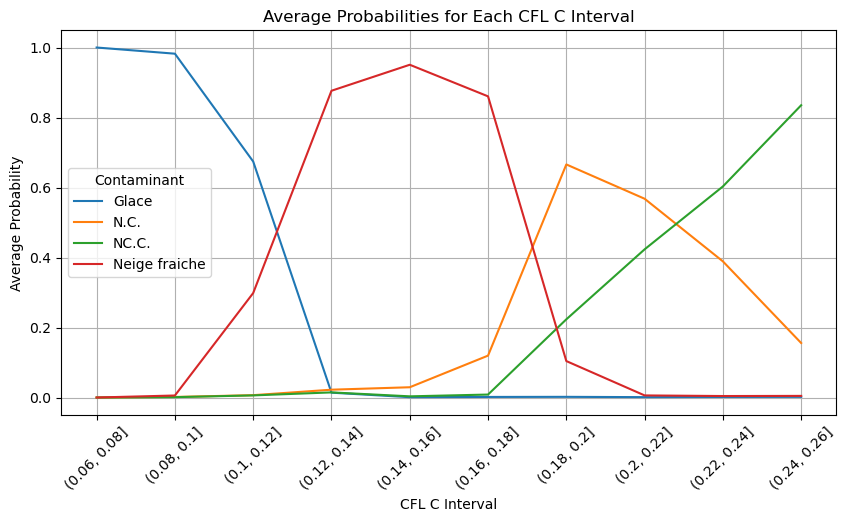

,Glace,N.C.,NC.C.,Neige fraiche,True Label,Predicted Label
"(0.06, 0.08]",1.000000,0.000000,0.000000,0.000000,Glace,Glace
"(0.08, 0.1]",0.982362,0.001567,0.001021,0.005754,Glace,Glace
"(0.1, 0.12]",0.674267,0.006717,0.006044,0.298491,Glace,Glace
"(0.12, 0.14]",0.013839,0.022355,0.014618,0.876457,Neige fraiche,Neige fraiche
"(0.14, 0.16]",0.000975,0.029337,0.003363,0.950751,Neige fraiche,Neige fraiche
"(0.16, 0.18]",0.001642,0.119699,0.008466,0.860472,Neige fraiche,Neige fraiche
"(0.18, 0.2]",0.001922,0.665926,0.223421,0.104124,N.C.,N.C.
"(0.2, 0.22]",0.001080,0.567919,0.423355,0.005988,N.C.,N.C.
"(0.22, 0.24]",0.001594,0.388989,0.603034,0.004252,NC.C.,NC.C.
"(0.24, 0.26]",0.001852,0.155695,0.835108,0.004639,NC.C.,NC.C.


In [74]:
dff = scale_encode(df, 0).copy()
# Filtrage des données
X_65_15 = dff[(~(dff["contaminant"].isin(["Verglas", "SLUSH"])))][['Moyenne CFL C','Moyenne G% [%]','Vitesse_65','Moyenne CFL F']].copy()
X_65_15 = X_65_15[(X_65_15['Moyenne G% [%]'] > 14) & (X_65_15['Moyenne G% [%]'] < 16) & (X_65_15.Vitesse_65 == 1)]

# Calcul des nouvelles colonnes
X_65_15["epsilon"] = abs(X_65_15["Moyenne CFL C"] - X_65_15['Moyenne CFL F'])
X_65_15["V*CFL"] = X_65_15['Vitesse_65'] * X_65_15["Moyenne CFL C"]
X_65_15["g*CFL"] = X_65_15['Moyenne G% [%]'] * X_65_15["Moyenne CFL C"]
X_65_15["g*V*CFL"] = X_65_15['Moyenne G% [%]'] * X_65_15['Vitesse_65'] * X_65_15["Moyenne CFL C"]
X_65_15 = X_65_15.drop(['Moyenne CFL F'],axis=1)


# Renommage des colonnes pour correspondre au modèle
X_65_15.columns = ['Moyenne_CFL_C', 'g','Vitesse_65','epsilon', 'V*CFL', 'g*CFL','g*V*CFL']

# Définition de y_65_15
y_65_15 = dff[(~(dff["contaminant"].isin(["Verglas", "SLUSH"]))) & 
              (dff['Moyenne G% [%]'] > 14) & 
              (dff['Moyenne G% [%]'] < 16) & 
              (dff.Vitesse_65 == 1)]['contaminant']

# Prédiction des probabilités
y_proba_xgb = best_xgb.predict_proba(X_65_15)

# Création du DataFrame de résultats
results_df = pd.DataFrame(X_65_15.reset_index(), columns=['Moyenne_CFL_C'])
results_df['True Label'] = y_65_15.values
results_df = results_df.join(pd.DataFrame(y_proba_xgb, columns=best_xgb.classes_))

# Mapping function for predicted labels
def f(x):
    if x == 0:
        return "Glace"
    elif x == 1:
        return 'N.C.'
    elif x == 2:
        return 'NC.C.'
    elif x == 3:
        return 'Neige fraiche'
    else:
        return 'SLUSH'
        
results_df['Predicted Label'] = results_df[best_xgb.classes_].idxmax(axis=1).apply(f)
results_df.columns = ['Moyenne_CFL_C', 'True Label', 'Glace', 'N.C.', 'NC.C.', 'Neige fraiche', 'SLUSH', 'Predicted Label']

# Définition des bins personnalisés avec un pas de 0.02
bin_edges = np.arange(0.08, 0.27, 0.02)
results_df['CFL_C_Interval'] = pd.cut(results_df['Moyenne_CFL_C'], bins=bin_edges)

# Calcul des probabilités et des valeurs les plus fréquentes
interval_probs = results_df.groupby('CFL_C_Interval')[['Glace', "N.C.", "NC.C.", "Neige fraiche"]].mean()
interval_counts = results_df.groupby('CFL_C_Interval')[['True Label', 'Predicted Label']].agg(lambda x: x.value_counts().index[0])
interval_probs = interval_probs.join(interval_counts)

# Ajout de la première ligne spécifiée
first_row = pd.DataFrame({
    'Glace': [1.0],
    'N.C.': [0.0],
    'NC.C.': [0.0],
    'Neige fraiche': [0.0],
    'True Label': ['Glace'],
    'Predicted Label': ['Glace']
}, index=pd.IntervalIndex.from_tuples([(0.06, 0.08)], closed='right'))

interval_probs = pd.concat([first_row, interval_probs])

# Fonction pour trouver la colonne avec la valeur maximale
def find_max_label(row):
    return row[['Glace', 'N.C.', 'NC.C.', 'Neige fraiche']].idxmax()

# Mise à jour de la colonne 'Predicted Label'
interval_probs["Predicted Label"] = interval_probs.apply(find_max_label, axis=1)

# Affichage des résultats
plt.figure(figsize=(10, 5))
for class_label in ['Glace', "N.C.", "NC.C.", "Neige fraiche"]:
    plt.plot(interval_probs.index.astype(str), interval_probs[class_label], label=class_label)
plt.xlabel('CFL C Interval')
plt.ylabel('Average Probability')
plt.title('Average Probabilities for Each CFL C Interval')
plt.legend(title='Contaminant')
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Affichage du DataFrame interval_probs
(interval_probs)
